In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

from src.graphs import StaticGraph
from src.misc import graph_matchings_parallel
from qiskit.quantum_info import Operator

from qiskit import QuantumCircuit, transpile

import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np

Original graph:


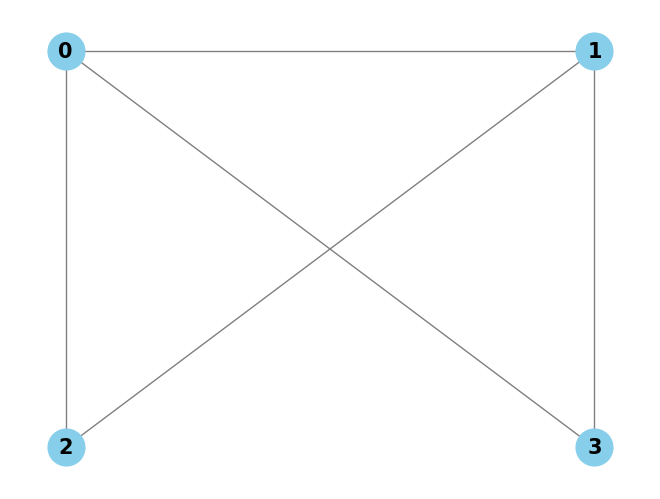

In [2]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11'), ('00', '01')}

delta_t = 0.1

G = StaticGraph(edges)
G.rot_angle = delta_t
print("Original graph:")
G.draw()

Relabeled graph:


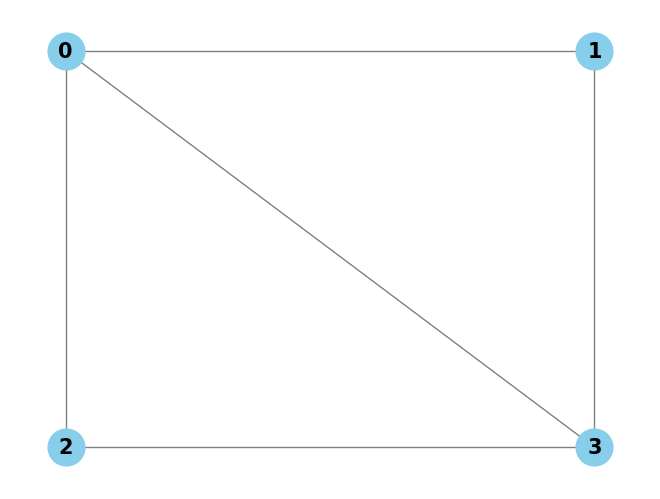

None

In [3]:
matchings = graph_matchings_parallel(edges)

relabeled_edges = set()
for m in matchings:
    relabeled_edges = relabeled_edges.union(m)

relabeled_G = StaticGraph(relabeled_edges)
print("Relabeled graph:")
display(relabeled_G.draw())

In [4]:
# Exact time evolution: U(t) = exp(-iHt)
from scipy.linalg import expm # type: ignore

relabeled_G = StaticGraph(relabeled_edges)
H = relabeled_G.get_adj_mat()
n_qubits = relabeled_G.n_qubits

exact_op = expm(-1j * H * delta_t)
exact_operator = Operator(exact_op)

In [7]:
exact_operator.data.round(3)

array([[ 0.985+0.001j, -0.005-0.099j, -0.005-0.099j, -0.01 -0.099j],
       [-0.005-0.099j,  0.99 +0.j   , -0.01 +0.j   , -0.005-0.099j],
       [-0.005-0.099j, -0.01 +0.j   ,  0.99 +0.j   , -0.005-0.099j],
       [-0.01 -0.099j, -0.005-0.099j, -0.005-0.099j,  0.985+0.001j]])

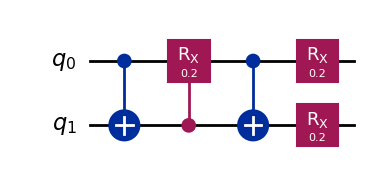

n_steps =   1: ||Matching - exact||_2 = 0.099958
n_steps =   1: ||Pauli - exact||_2 = 0.009953
n_steps =   1: ||Matching - Pauli||_2 = 0.099958



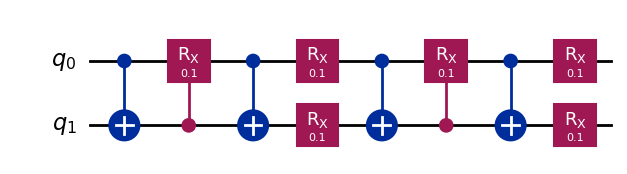

n_steps =   2: ||Matching - exact||_2 = 0.099958
n_steps =   2: ||Pauli - exact||_2 = 0.004968
n_steps =   2: ||Matching - Pauli||_2 = 0.099958



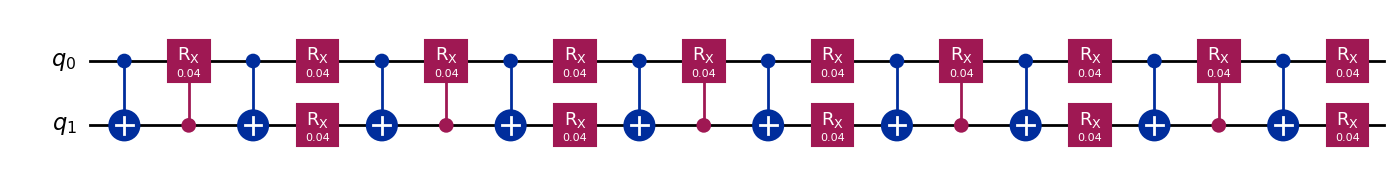

n_steps =   5: ||Matching - exact||_2 = 0.099958
n_steps =   5: ||Pauli - exact||_2 = 0.001986
n_steps =   5: ||Matching - Pauli||_2 = 0.099958



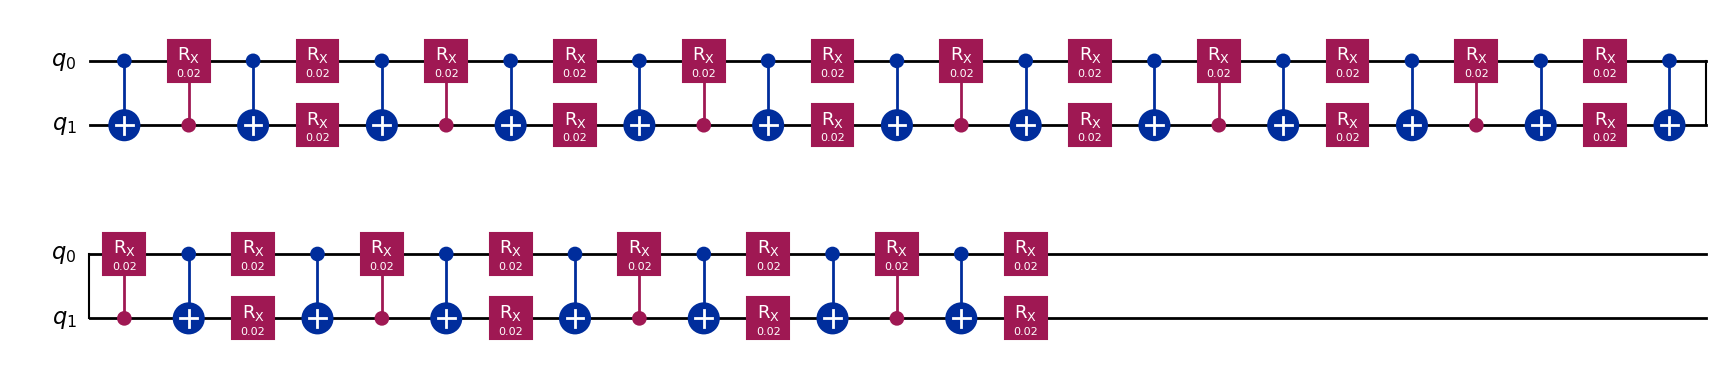

n_steps =  10: ||Matching - exact||_2 = 0.099958
n_steps =  10: ||Pauli - exact||_2 = 0.000993
n_steps =  10: ||Matching - Pauli||_2 = 0.099958



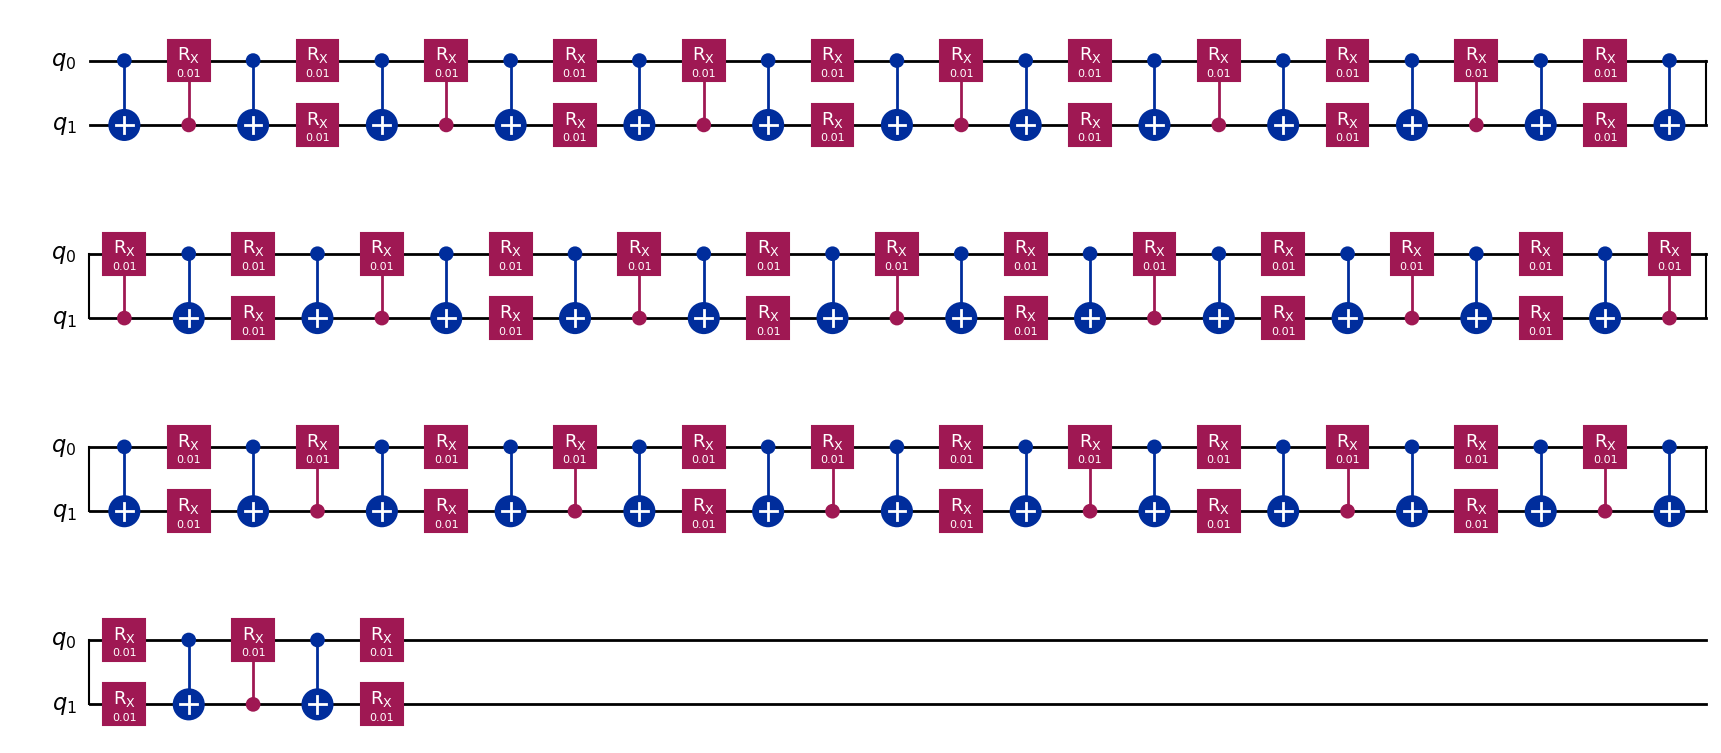

n_steps =  20: ||Matching - exact||_2 = 0.099958
n_steps =  20: ||Pauli - exact||_2 = 0.000496
n_steps =  20: ||Matching - Pauli||_2 = 0.099958



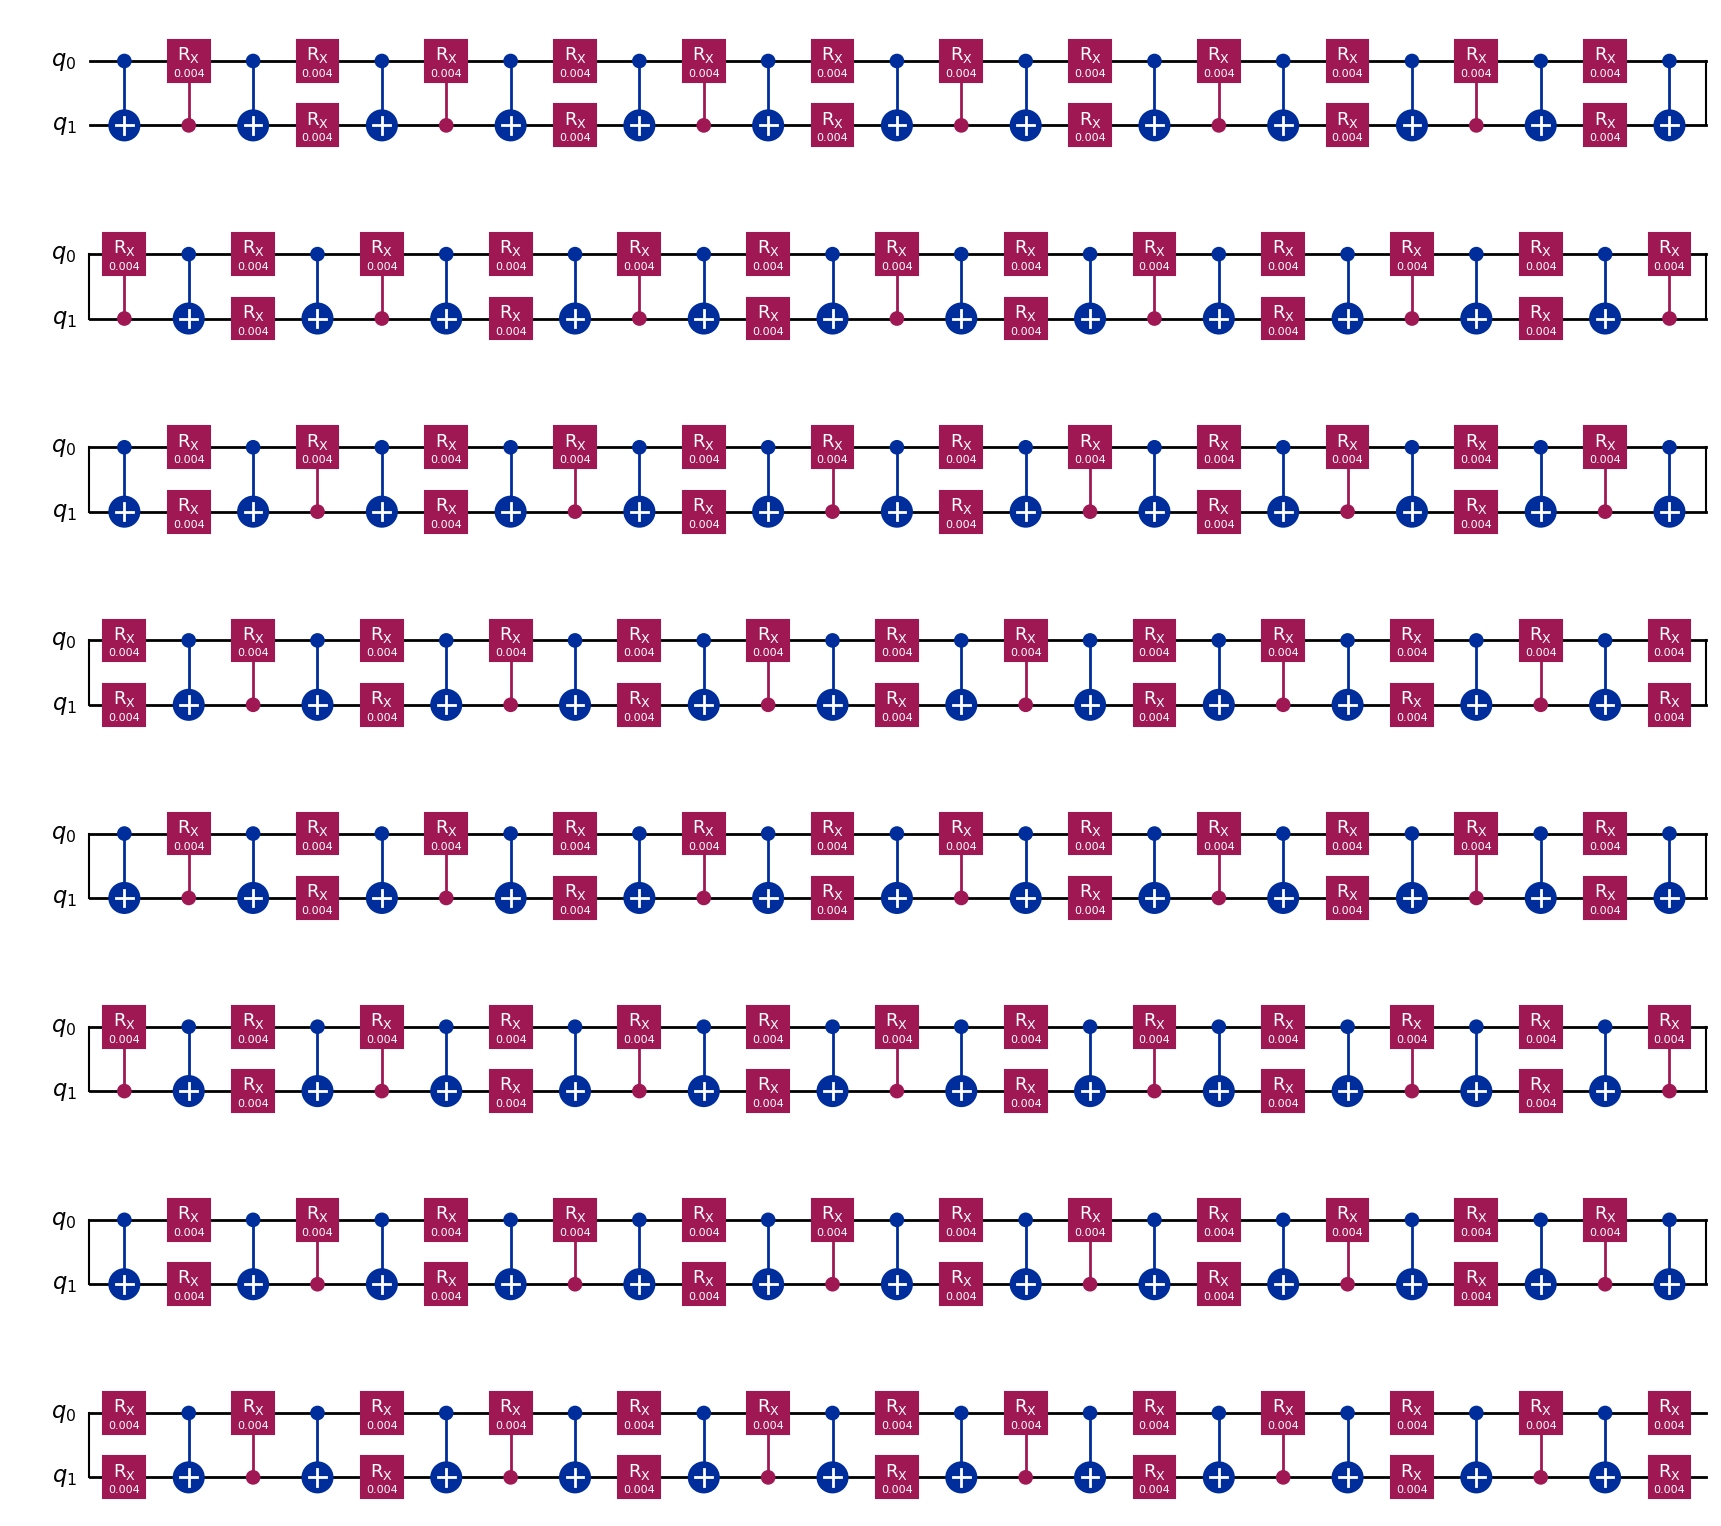

n_steps =  50: ||Matching - exact||_2 = 0.099958
n_steps =  50: ||Pauli - exact||_2 = 0.000199
n_steps =  50: ||Matching - Pauli||_2 = 0.099958



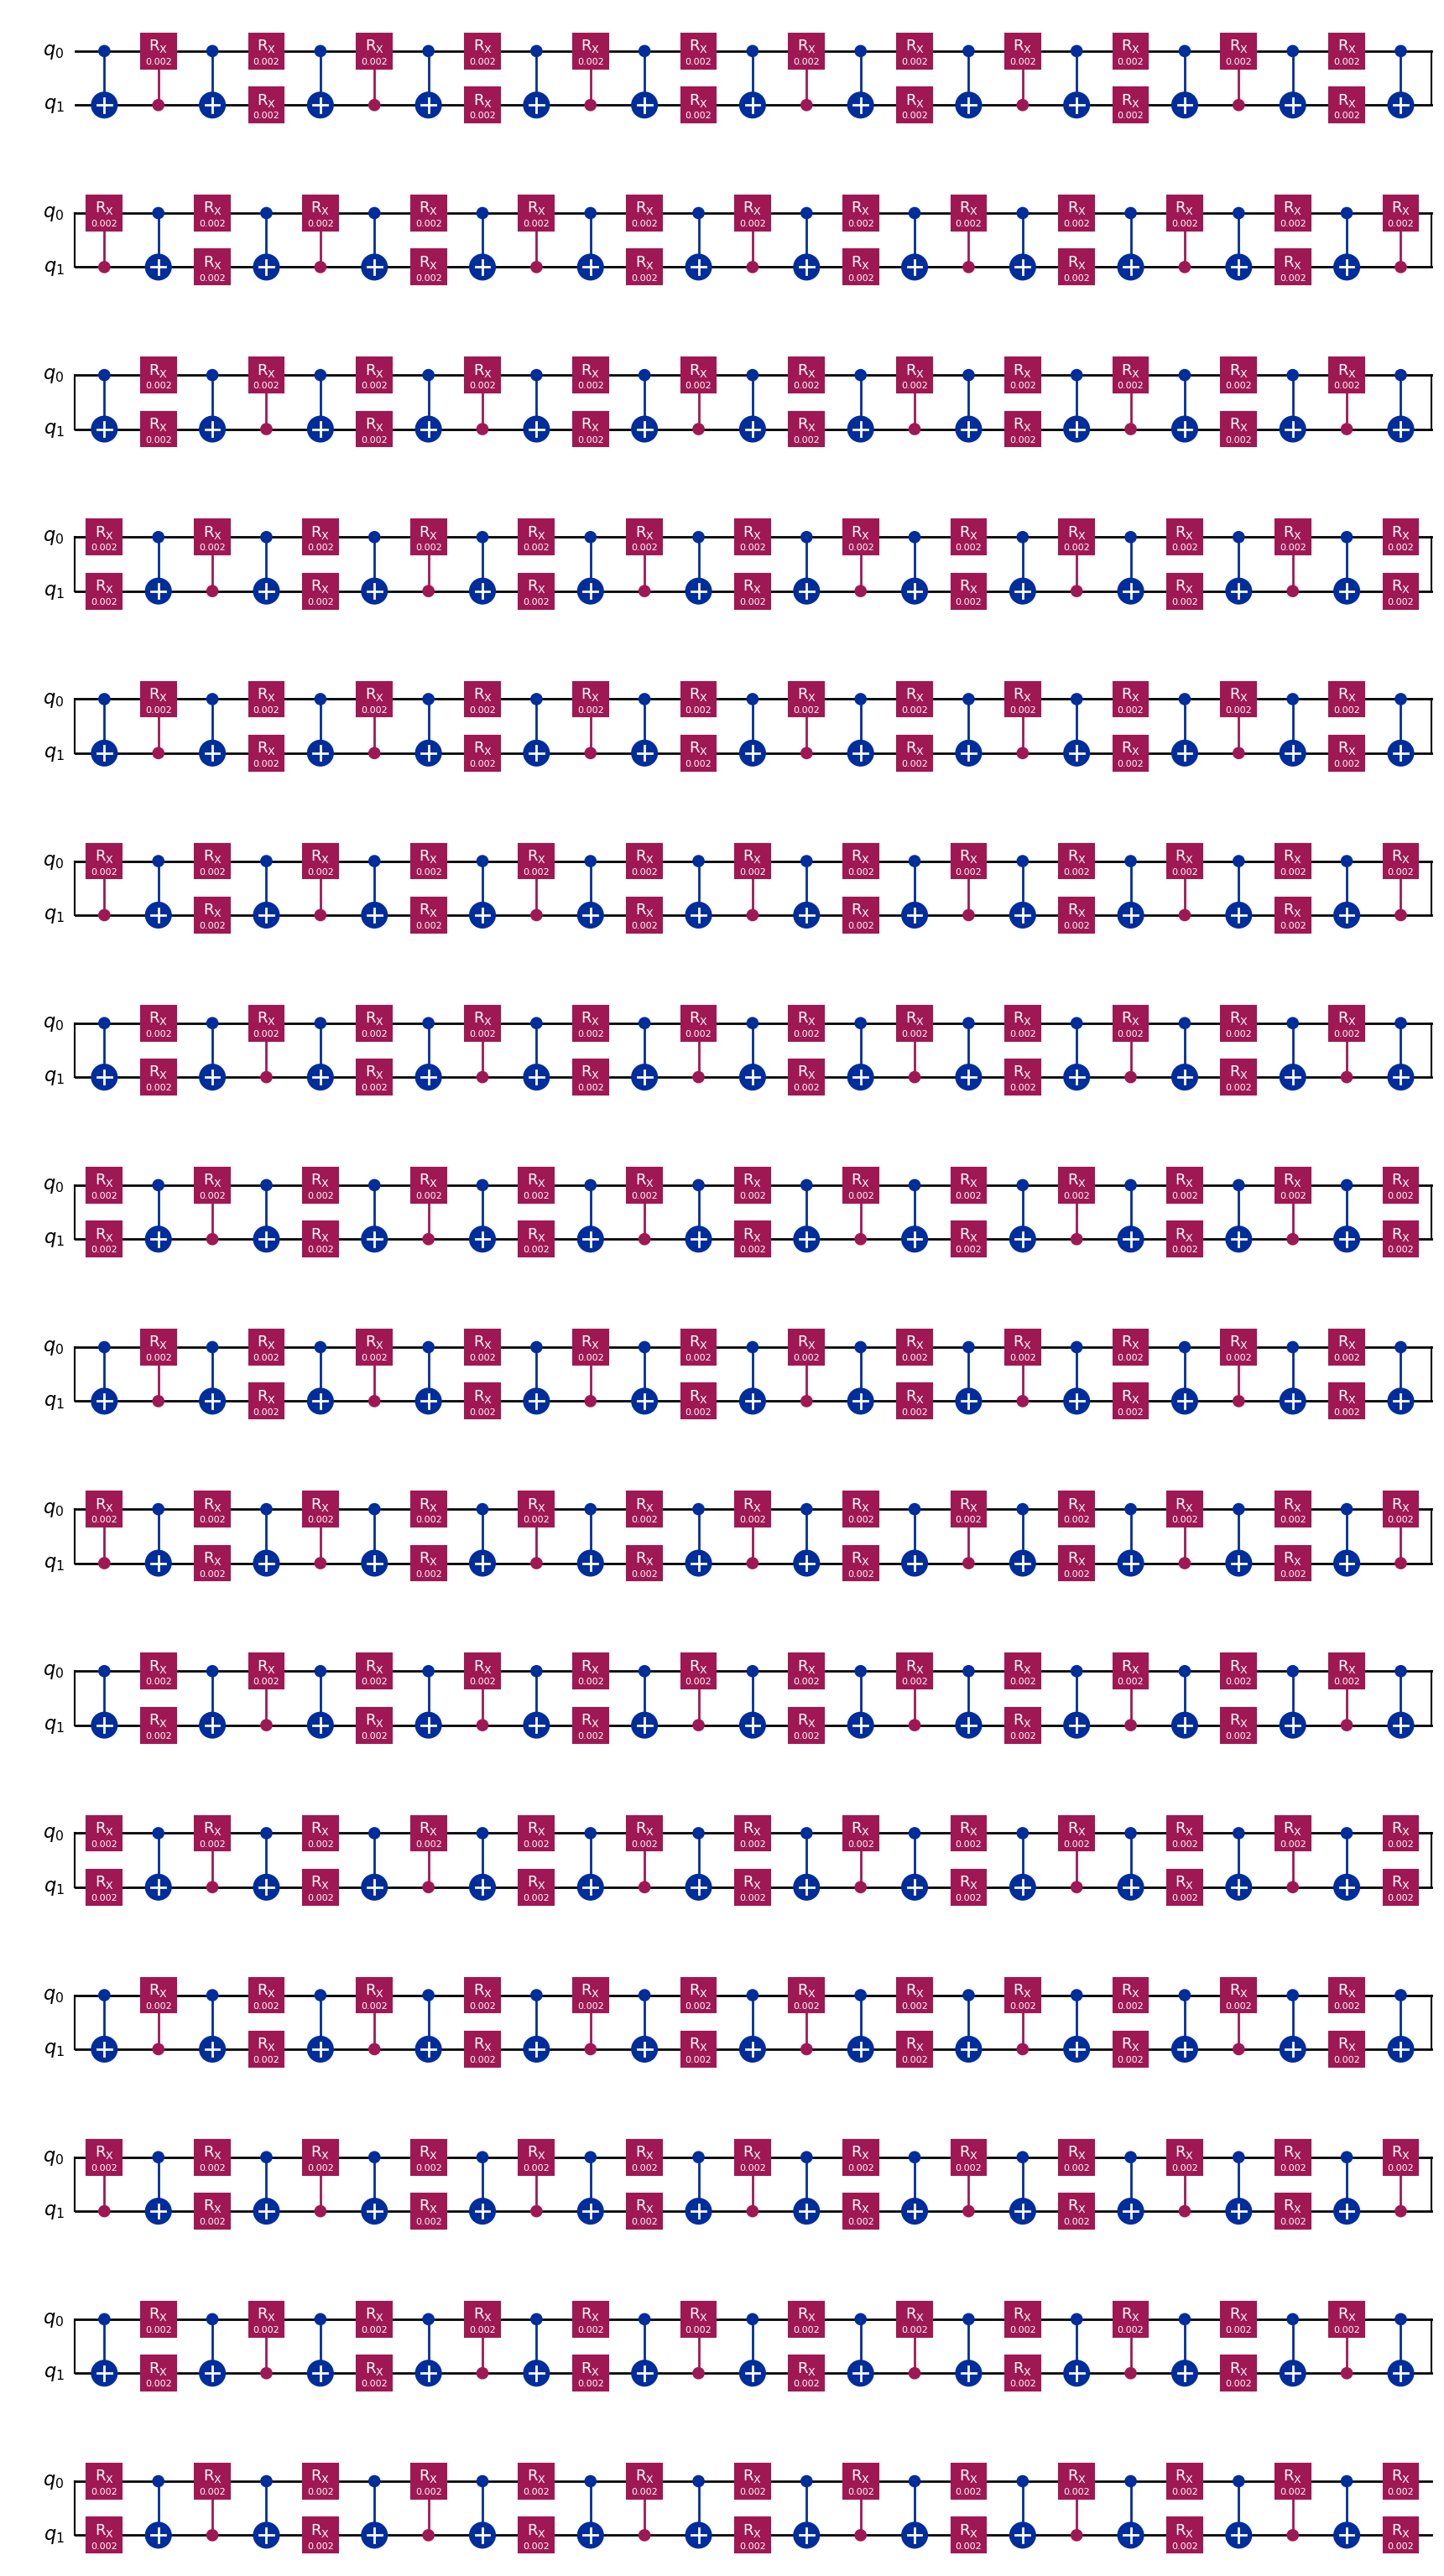

n_steps = 100: ||Matching - exact||_2 = 0.099958
n_steps = 100: ||Pauli - exact||_2 = 0.000099
n_steps = 100: ||Matching - Pauli||_2 = 0.099958



In [5]:
n_steps_list = [1, 2, 5, 10, 20, 50, 100]

delta_t = 0.1

for n_steps in n_steps_list:

    full_qc = QuantumCircuit(n_qubits)
    for i in range(n_steps):
        
        full_qc.cx(0, 1)
        full_qc.crx(2 * delta_t/n_steps, 1, 0)
        full_qc.cx(0, 1)

        full_qc.rx(2 * delta_t/n_steps, 0)
        full_qc.rx(2 * delta_t/n_steps, 1)
    
    display(full_qc.draw('mpl'))
    # Final result
    matching_operator = Operator(full_qc)

    
    H = relabeled_G.get_adj_mat()
    n = relabeled_G.n_qubits
    
    # Decompose Hamiltonian into Pauli basis
    pauli_strings = []
    coeffs = []
    
    for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ H) / (2**n)
        
        real_coeff = float(np.real(coeff))
        if not np.isclose(real_coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(real_coeff)
    
    # Initialize with identity operator
    identity_dim = 2**n
    pauli_operator = Operator(np.eye(identity_dim, dtype=complex))
    
    if coeffs:
        # Time per Trotter step
        dt = delta_t / n_steps
        
        # Accumulate operators in the loop (first-order Trotter decomposition)
        for step in range(n_steps):
            # Apply each Pauli term separately (first-order Trotter)
            for pauli_string, coeff in zip(pauli_strings, coeffs):
                single_pauli_op = SparsePauliOp([pauli_string], [coeff])
                evo_gate = PauliEvolutionGate(single_pauli_op, time=dt)
                
                # Convert to circuit and then to operator
                temp_qc = QuantumCircuit(n)
                temp_qc.append(evo_gate, range(n))
                
                # Decompose to get actual gates and convert to operator
                decomposed_qc = transpile(temp_qc, basis_gates=['cx', 'u3'], optimization_level=3)
                step_operator = Operator(decomposed_qc)
                
                # Compose with accumulated operator
                pauli_operator = step_operator.compose(pauli_operator)
    
    # Calculate difference
    matching_vs_pauli = matching_operator - pauli_operator
    matching_vs_exact = matching_operator - exact_operator
    pauli_vs_exact = pauli_operator - exact_operator

    print(f"n_steps = {n_steps:3d}: ||Matching - exact||_2 = {np.linalg.norm(matching_vs_exact, ord=2):.6f}")
    print(f"n_steps = {n_steps:3d}: ||Pauli - exact||_2 = {np.linalg.norm(pauli_vs_exact, ord=2):.6f}")
    print(f"n_steps = {n_steps:3d}: ||Matching - Pauli||_2 = {np.linalg.norm(matching_vs_pauli, ord=2):.6f}")
    print()